In [1]:
import pickle
import random
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Autoencoder, SirenNet
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [7]:
resolution = 16

smiles = ["C1CCCCC1"]

fd = FieldDataset(smiles, resolution=resolution)
dl = DataLoader(fd, batch_size=2, shuffle=True)
dl_test = DataLoader(fd, batch_size=2, shuffle=False)

def plot_field(field):
    arr = field.numpy()

    data = dict(density=(arr, "g/cm**3"))
    bbox = np.array([[0.0, 1.5], [0.0, 1.5], [0.0, 1.5]])
    ds = yt.load_uniform_grid(data, arr.shape, length_unit="Mpc", nprocs=64)
    sc = yt.create_scene(ds)

    cam = sc.add_camera(ds, lens_type="plane-parallel")
    cam.resolution = [512, 512]
    sc.show()
    return sc

yt : [INFO     ] 2025-02-08 00:29:38,121 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-08 00:29:38,121 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-08 00:29:38,121 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-08 00:29:38,121 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-08 00:29:38,122 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-08 00:29:38,167 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-08 00:29:38,174 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-08 00:29:38,174 Creating volume
yt : [INFO     ] 2025-02-08 00:29:38,190 Creating transfer function
yt : [INFO     ] 2025-02-08 00:29:38,190 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


torch.Size([16, 16, 16, 12])


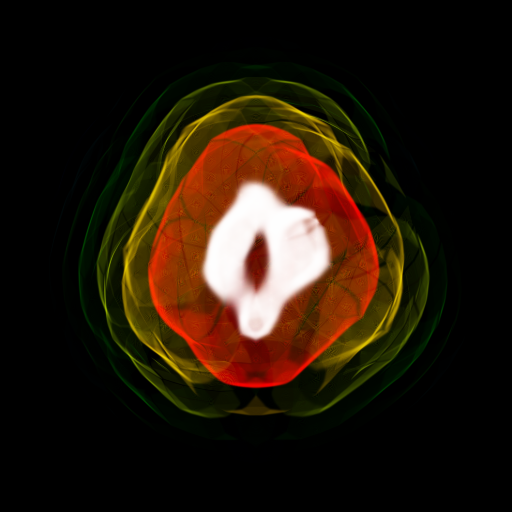

In [8]:
for batch in dl_test:
    for vector_field in batch:
        print(vector_field.shape)
        plot_field(vector_field[:, :, :, 1])
    break

In [12]:
net = SirenNet(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

siren_decoder = Autoencoder(
    net,
    in_channels=12,
    output_shape=[resolution, resolution, resolution, 12, 1],
    # output_shape=[resolution, resolution, resolution, 1, 1],
    latent_dim=256,
)

siren_decoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=siren_decoder.parameters())

In [13]:
for epoch in (pbar := tqdm(range(2000))):
    total_loss = 0
    for batch in dl:
        step_loss = 0
        loss, out, latent = siren_decoder(batch.cuda())
        optim.zero_grad()
        loss.backward()
        optim.step()

        total_loss += loss.item()
    torch.save(siren_decoder.state_dict(), "model.pt")
    pbar.set_description(f"Epoch {epoch} (loss: {(total_loss / len(fd)):2f})")

Epoch 1999 (loss: 0.004481): 100%|███████████████████████████████████████████████████████████████████████| 2000/2000 [01:14<00:00, 26.97it/s]


yt : [INFO     ] 2025-02-08 00:36:57,748 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-08 00:36:57,748 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-08 00:36:57,748 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-08 00:36:57,749 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-08 00:36:57,749 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-08 00:36:57,791 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-08 00:36:57,797 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-08 00:36:57,798 Creating volume
yt : [INFO     ] 2025-02-08 00:36:57,814 Creating transfer function
yt : [INFO     ] 2025-02-08 00:36:57,814 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


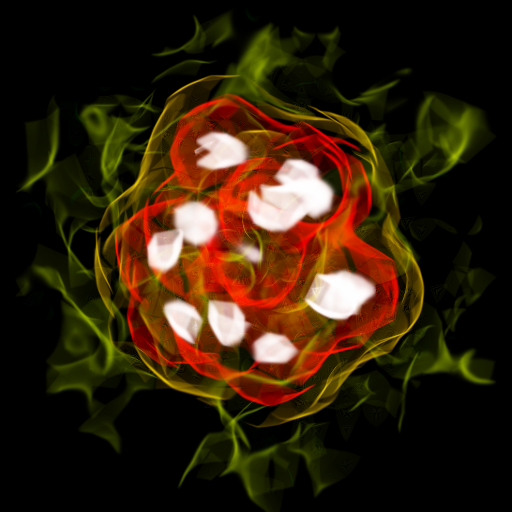

yt : [INFO     ] 2025-02-08 00:36:58,085 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-08 00:36:58,085 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-08 00:36:58,085 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-08 00:36:58,085 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-08 00:36:58,085 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-08 00:36:58,128 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-08 00:36:58,135 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-08 00:36:58,135 Creating volume
yt : [INFO     ] 2025-02-08 00:36:58,151 Creating transfer function
yt : [INFO     ] 2025-02-08 00:36:58,151 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


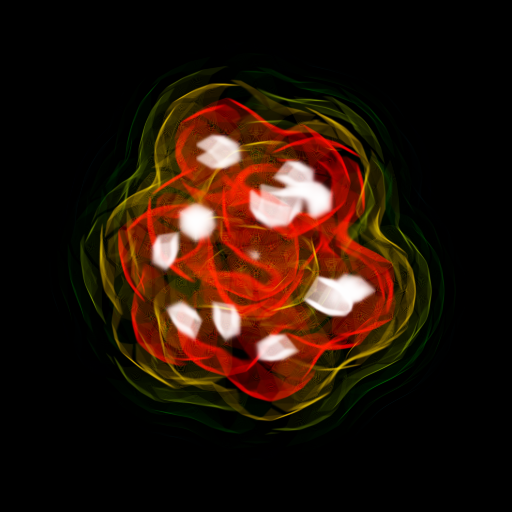

In [18]:
i = 0
for batch in dl_test:
    latent = siren_decoder.encode(batch.cuda())
    reconstructed = siren_decoder.predict(latent).cpu().detach()
    
    for r in reconstructed:
        plot_field(r.flatten(3)[:, :, :, 0])
        print("gt")
        plot_field(fd[i][:, :, :, 0])
        i += 1
    break